### LIBRARY
Melakukan proses import library yang digunakan dalam pengolahan citra. Library numpy dimanfaatkan untuk memproses matriks pada gambar, matplotlib digunakan untuk menampilkan visualisasi data maupun citra, sedangkan opencv berfungsi dalam proses pengolahan gambar serta pengenalan pola.

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## MEMBACA, MENAMPILKAN, DAN PEMBERIAN NAMA PADA GAMBAR

Membaca citra Bunga, Langit, Meledak, dan Windut menggunakan cv2.imread dengan paramater lokasi file dalam folder Assets. menggunakan plt.imshow untuk menampilkan gambar dengan mengunci color pada warna abu.

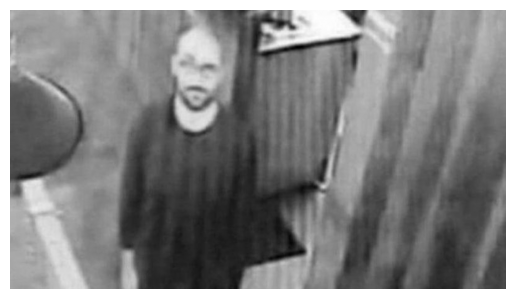

In [120]:
orang = cv2.imread("backup.jpg")
orangAbu = cv2.cvtColor(orang, cv2.COLOR_BGR2GRAY)

plt.imshow(orangAbu, cmap='gray')
plt.axis(False)
plt.show()


## Sliding Window (Filter mean, median, modus)

Fungsi filter adalah implementasi pemrosesan citra yang dilakukan secara manual dengan cara menggeser sebuah kernel berukuran tertentu ke setiap bagian gambar. Sebelum proses dilakukan, gambar terlebih dahulu diberi padding agar piksel di bagian tepi tetap dapat diproses dengan baik. 

Pada mode mean, nilai piksel diperoleh dari rata-rata seluruh elemen di area kernel sehingga citra tampak lebih halus. 

Mode median bekerja dengan mengurutkan nilai piksel lalu mengambil nilai tengah untuk mengurangi noise atau bintik-bintik gangguan pada gambar. 

Sementara itu, mode modus menentukan nilai piksel berdasarkan angka yang paling sering muncul di area tersebut. Semua hasil perhitungan kemudian disimpan ke dalam matriks baru sehingga menghasilkan citra akhir yang telah diproses sesuai metode filter yang digunakan.

In [121]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for r in range(size):
                        for c in range(size):
                            total += int(region[r, c])
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = [0] * (size * size)
                    for r in range(size):
                        for c in range(size):
                            values[r * size + c] = int(region[r, c])

                    n = size * size
                    for x in range(n - 1):
                        for y in range(n - x - 1):
                            if values[y] > values[y + 1]:
                                values[y], values[y + 1] = values[y + 1], values[y]

                    canvas[i, j] = values[n // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas

## Fungsi Konvolusi

Fungsi convolution merupakan teknik pemrosesan citra yang dilakukan dengan menggeser sebuah matriks kecil yang disebut kernel ke seluruh area gambar untuk menghasilkan nilai piksel baru. Nilai baru tersebut diperoleh melalui kombinasi linear antara elemen kernel dan area piksel di sekitarnya. Sebelum proses konvolusi dilakukan, citra biasanya diberi padding atau bingkai tambahan agar dimensi hasil keluaran tetap sama dengan gambar asli.

In [122]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

## Kernel Perbaikan Citra

In [123]:
# Kernel rata-rata 3x3 (Box Blur)
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

# Kernel Sharpening yang menonjolkan titik pusat
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])



## Kernel Sobel

In [124]:
# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32) #

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32) #

## Kernel Prewitt

In [125]:
# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1,  0,  1],
    [-1,  0,  1],
    [-1,  0,  1]
], dtype=np.float32) #

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32) #

## Kernel Roberts

In [126]:
# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

# kernel roberts sumbu y / y-axis roberts kernel
robertsY = np.array([
    [0,  1],
    [-1, 0]
], dtype=np.float32)

In [127]:
orangSmooth = convolution(orangAbu, kernelSmoothing)
orangSharp = convolution(orangAbu, kernelSharpening)
orangSmoothSharp = convolution(orangSharp, kernelSmoothing)

In [ ]:
orangMean3 = filter(orangAbu, 3, 'mean')
orangMean9 = filter(orangAbu, 9, 'mean')
orangMedian3 = filter(orangAbu, 3, 'median')
orangMedian9 = filter(orangAbu, 9, 'median')
orangModus3 = filter(orangAbu, 3, 'modus')
orangModus9 = filter(orangAbu, 9, 'modus')

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

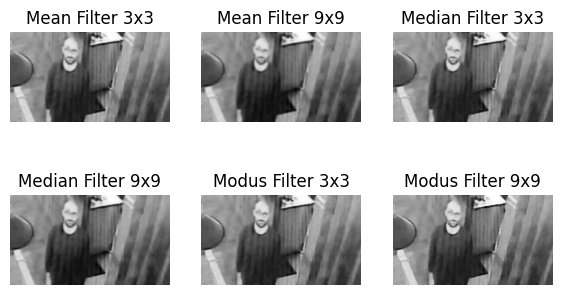

In [ ]:
plt.figure(figsize=(7,6))
plt.subplot(3,3,1)
plt.imshow(orangMean3, cmap = 'gray')
plt.title('Mean Filter 3x3')
plt.axis('off')
plt.subplot(3,3,2)
plt.imshow(orangMean9, cmap = 'gray')
plt.title('Mean Filter 9x9')
plt.axis('off')
plt.subplot(3,3,3)
plt.imshow(orangMedian3, cmap = 'gray')
plt.title('Median Filter 3x3')
plt.axis('off')
plt.subplot(3,3,4)
plt.imshow(orangMedian9, cmap = 'gray')
plt.title('Median Filter 9x9')
plt.axis('off')
plt.subplot(3,3,5)
plt.imshow(orangModus3, cmap = 'gray')
plt.title('Modus Filter 3x3')
plt.axis('off')
plt.subplot(3,3,6)
plt.imshow(orangModus9, cmap = 'gray')
plt.title('Modus Filter 9x9')
plt.axis('off')

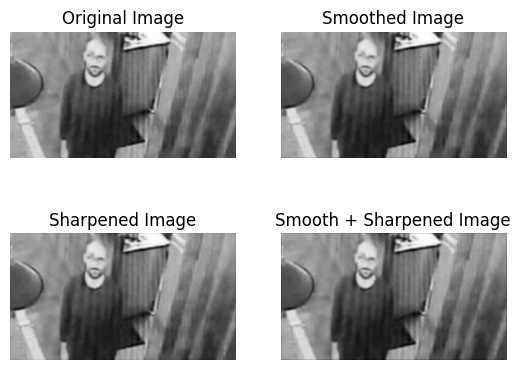

In [ ]:
plt.subplot(2,2,1)
plt.imshow(orangAbu, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(orangSmooth, cmap = 'gray')
plt.title('Smoothed Image')
plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(orangSharp, cmap = 'gray')
plt.title('Sharpened Image')
plt.axis('off')
plt.subplot(2,2,4)
plt.imshow(orangSmoothSharp, cmap = 'gray')
plt.title('Smooth + Sharpened Image')
plt.axis('off')

plt.show()

Perbedaan pada ketiga gambar tersebut adalah pada citra smoothing citra akan terlihat lebih lembut dan halus, sedangkan pada citra sharpering kontras citra akan meningkat dan mempertegas detil pada citra. saat smooting dan sharpering digabungkan maka citra akan terlihat lebih lembut dan memiliki kontras tinggi.

## Fungsi Edge Detection

Fungsi edge merupakan implementasi deteksi tepi pada citra digital yang bertujuan untuk menemukan perubahan intensitas warna pada gambar. Proses ini dilakukan dengan menghitung gradien menggunakan operasi konvolusi memakai dua kernel berbeda, misalnya kernel Sobel, untuk mendeteksi perubahan pada arah horizontal dan vertikal. Dari hasil konvolusi tersebut, diperoleh informasi mengenai kekuatan perubahan intensitas pada setiap arah.

In [ ]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

In [ ]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

In [ ]:
orangTepian_sobel = edge(orangSmoothSharp, sobelX, sobelY)
orangTepian_sobel = normalisasi(orangTepian_sobel)

orangTepian_prewitt = edge(orangSmoothSharp, prewittX, prewittY)
orangTepian_prewitt = normalisasi(orangTepian_prewitt)

orangTepian_roberts = edge(orangSmoothSharp, robertsX, robertsY)
orangTepian_roberts = normalisasi(orangTepian_roberts)


In [ ]:
prewittXsobel = normalisasi(orangTepian_sobel + orangTepian_prewitt)

prewittXroberts = normalisasi(orangTepian_prewitt + orangTepian_roberts)

sobelXroberts = normalisasi(orangTepian_sobel + orangTepian_roberts)

prewittXsobelXroberts = normalisasi(orangTepian_sobel + orangTepian_prewitt + orangTepian_roberts)

prewittXsobelXroberts = normalisasi(prewittXsobelXroberts)



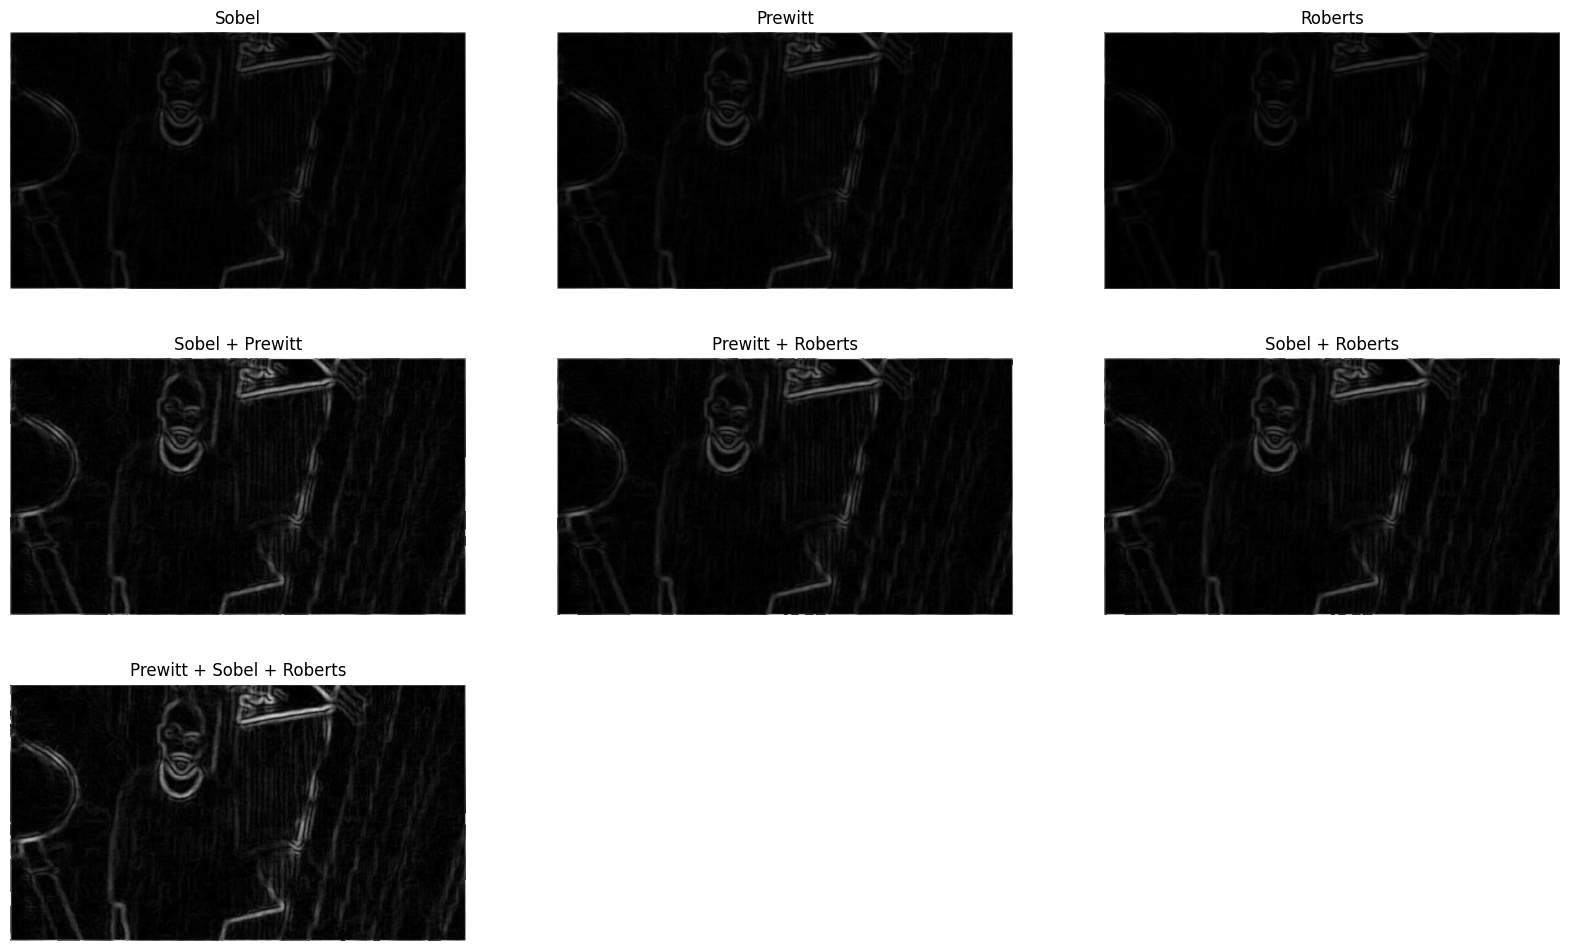

In [ ]:
plt.figure(figsize=(20, 12))
plt.subplot(3,3,1)
plt.imshow(orangTepian_sobel, cmap = 'gray')
plt.title('Sobel')
plt.axis('off')
plt.subplot(3,3,2)
plt.imshow(orangTepian_prewitt, cmap = 'gray')
plt.title('Prewitt')
plt.axis('off')
plt.subplot(3,3,3)
plt.imshow(orangTepian_roberts, cmap = 'gray')
plt.title('Roberts')
plt.axis('off')
plt.subplot(3,3,4)
plt.imshow(prewittXsobel, cmap = 'gray')
plt.title('Sobel + Prewitt')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(prewittXroberts, cmap = 'gray')
plt.title('Prewitt + Roberts')
plt.axis('off')
plt.subplot(3,3,6)
plt.imshow(sobelXroberts, cmap = 'gray')
plt.title('Sobel + Roberts')
plt.axis('off')
plt.subplot(3,3,7)
plt.imshow(prewittXsobelXroberts, cmap = 'gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')


plt.show()

1. Operator Sobel digunakan  untuk  mendeteksi  garis  tepi  (edge)  pada  gambar  dengan menyoroti perubahan warna atau kontras yang tajam secara horizontal dan vertikal, dan memberikan efek halus dan sedikit noise.

2. Operator Prewitt mirip seperti sobel tetapi tanpa penghalusan pada titik sengah dan sensitif terhadap noise.

3. Operator Roberts untuk mendeteksi garis tepi dengan menghitung 
perbedaan  kontras  secara  diagonal, tetapi filter ini paling rentang terhadap noise.

In [ ]:
def treshold_tepi(img, thresh):
    height, width = img.shape
    canvas = np.zeros_like(img)
    for i in range(height):
        for j in range(width):
            if img[i, j] > thresh:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0
    return canvas

In [ ]:
orang_tres10 = treshold_tepi(orangTepian_sobel, 10)
orang_tres20 = treshold_tepi(orangTepian_sobel, 20)
orang_tres30 = treshold_tepi(orangTepian_sobel, 30)
orang_tres40 = treshold_tepi(orangTepian_sobel, 40)
orang_tres50 = treshold_tepi(orangTepian_sobel, 50)
orang_tres60 = treshold_tepi(orangTepian_sobel, 60)

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

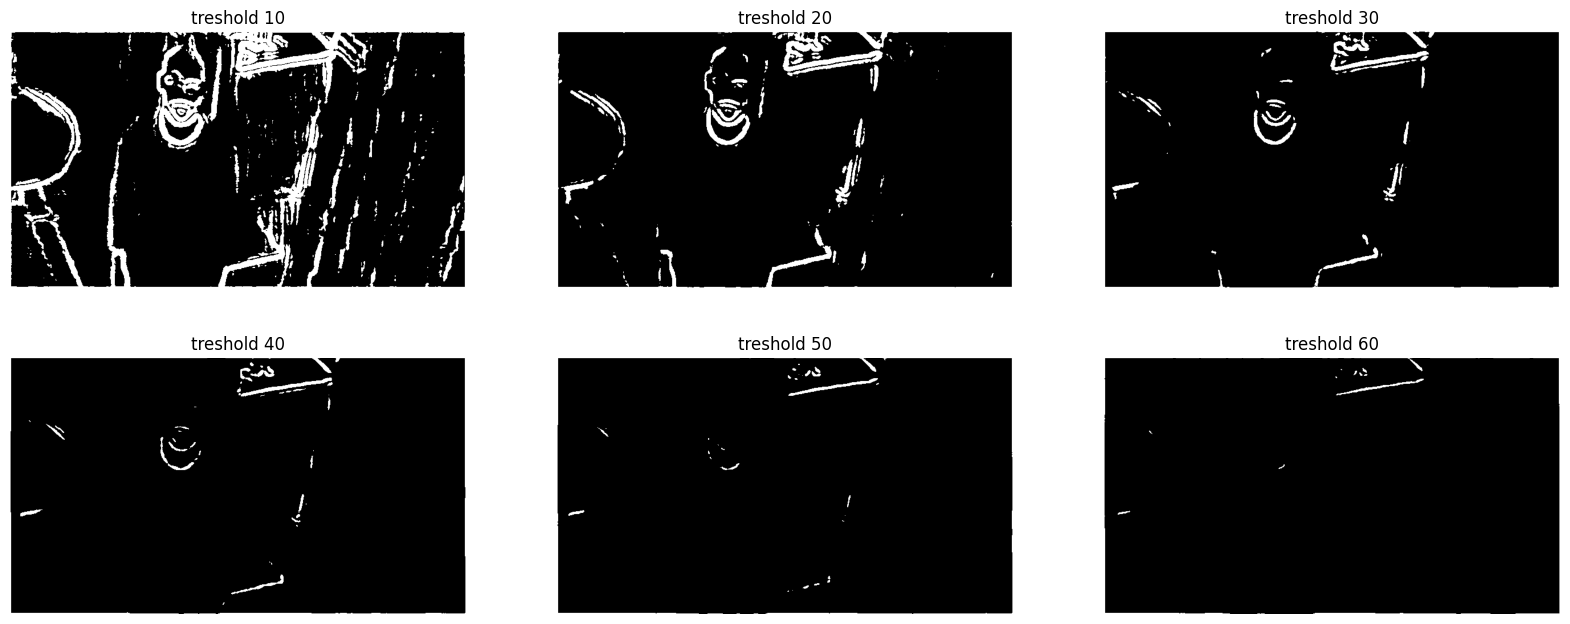

In [ ]:
plt.figure(figsize=(20, 12))

plt.subplot(3,3,1)
plt.imshow(orang_tres10, cmap = 'gray')
plt.title('treshold 10')
plt.axis('off')
plt.subplot(3,3,2)
plt.imshow(orang_tres20, cmap = 'gray')
plt.title('treshold 20')
plt.axis('off')
plt.subplot(3,3,3)
plt.imshow(orang_tres30, cmap = 'gray')
plt.title('treshold 30')
plt.axis('off')
plt.subplot(3,3,4)
plt.imshow(orang_tres40, cmap = 'gray')
plt.title('treshold 40')
plt.axis('off')
plt.subplot(3,3,5)
plt.imshow(orang_tres50, cmap = 'gray')
plt.title('treshold 50')
plt.axis('off')
plt.subplot(3,3,6)
plt.imshow(orang_tres60, cmap = 'gray')
plt.title('treshold 60')
plt.axis('off')

Berdasarkan hasil analisis, deteksi tepi menggunakan metode Prewitt dan Sobel masih dapat terlihat, tetapi intensitas tepinya cenderung kurang terang. Sementara itu, pada metode Roberts, hasil deteksi tepi tampak sangat redup bahkan hampir tidak terlihat. Ketika dilakukan penggabungan menggunakan dua maupun tiga kombinasi metode, hasil deteksi tepi menjadi lebih jelas dan memiliki intensitas yang semakin terang. Hal ini menunjukkan bahwa kombinasi beberapa operator mampu memperkuat informasi gradien pada citra. Selain itu, perlu diperhatikan bahwa setelah proses deteksi tepi dilakukan, citra juga melewati tahap normalisasi sehingga nilai intensitasnya disesuaikan kembali ke rentang standar agar hasil visualisasi lebih optimal.


In [ ]:
def gambar_garis_manual(canvas, p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    sx = 1 if x1 < x2 else -1
    sy = 1 if y1 < y2 else -1
    err = dx - dy

    while True:
        if 0 <= x1 < canvas.shape[1] and 0 <= y1 < canvas.shape[0]:
            canvas[int(y1), int(x1)] = 255
        if x1 == x2 and y1 == y2:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x1 += sx
        if e2 < dx:
            err += dx
            y1 += sy

def buat_masker_manual(h, w, titik):
    mask = np.zeros((h, w), dtype=np.uint8)
    n = len(titik)

    min_x = int(np.min(titik[:, 0]))
    max_x = int(np.max(titik[:, 0]))
    min_y = int(np.min(titik[:, 1]))
    max_y = int(np.max(titik[:, 1]))

    for y in range(min_y, max_y + 1):
        for x in range(min_x, max_x + 1):
            # Algoritma Ray Casting (Point in Polygon)
            didalam = False
            p1x, p1y = titik[0]
            for i in range(n + 1):
                p2x, p2y = titik[i % n]
                if y > min(p1y, p2y):
                    if y <= max(p1y, p2y):
                        if x <= max(p1x, p2x):
                            if p1y != p2y:
                                x_potong = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                            if p1x == p2x or x <= x_potong:
                                didalam = not didalam
                p1x, p1y = p2x, p2y
            
            if didalam:
                mask[y, x] = 255
    return mask

h, w = orangSmoothSharp.shape

titik_sudut = np.array([
    [305, 15],   # Puncak kepala
    [345, 45],   # Sisi kanan kepala
    [348, 70],  # Telinga kanan
    [345, 140],  # Leher kanan
    [365, 155],  # Bahu kanan
    [395, 250],  # Lengan kanan luar
    [390, 449],  # Badan bawah kanan
    [175, 449],  # Badan bawah kiri
    [170, 250],  # Lengan kiri luar
    [205, 150],  # Bahu kiri
    [265, 120],  # Leher kiri
    [255, 70],  # Telinga kiri
    [265, 45],  # Sisi kiri Kepala
], np.int32)

masker = np.zeros((h, w), dtype=np.uint8)
masker_detect = np.zeros((h, w), dtype=np.uint8)

masker = buat_masker_manual(h, w, titik_sudut)

for i in range(len(titik_sudut)):
    titik_sekarang = titik_sudut[i]
    titik_berikutnya = titik_sudut[(i + 1) % len(titik_sudut)]
    gambar_garis_manual(masker_detect, titik_sekarang, titik_berikutnya)

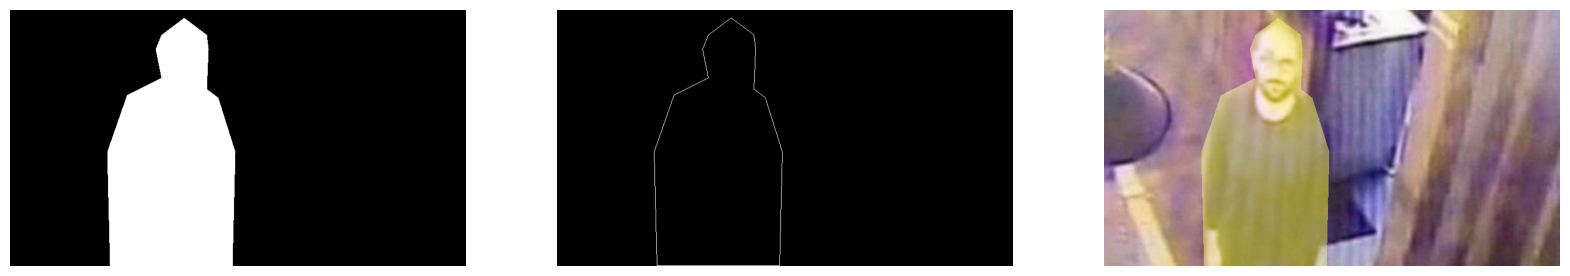

In [ ]:
orang_rgb = cv2.cvtColor(orang, cv2.COLOR_BGR2RGB)
cctvFinal = orang_rgb.copy()

for i in range(h):
    for j in range(w):
        if masker[i, j] == 255:
            cctvFinal[i, j, 0] = (cctvFinal[i, j, 0] * 0.5 + 255 * 0.5)
            cctvFinal[i, j, 1] = (cctvFinal[i, j, 1] * 0.5 + 255 * 0.5)

plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(masker, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(masker_detect, cmap = 'gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cctvFinal)
plt.axis('off')

plt.show()

Pada citra tersebut penggunaan dari tresholding adalah mengurangi noise pada citra. pada treshold rendah terlihat noise dan garis tepi masih terlihat dan banyak, sedangkan pada tresholding tinggi noise dan garis tepi semakin sedikit. tresholding yang paling bagus digunakan yaitu tresholding tinggi karena mengurangi noise dna membuat citra lebih jelas. 

# PAS FOTO

(788, 978, 3)


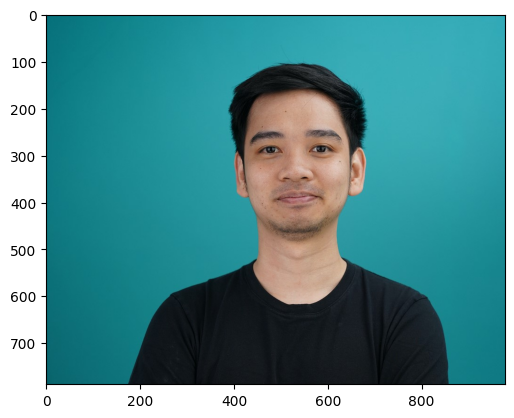

In [ ]:
david = cv2.imread('david.jpg')
davidAbu = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)
davidRGB = cv2.cvtColor(david, cv2.COLOR_BGR2RGB)
plt.imshow(davidRGB, cmap='gray')
plt.axis()
print(davidRGB.shape)



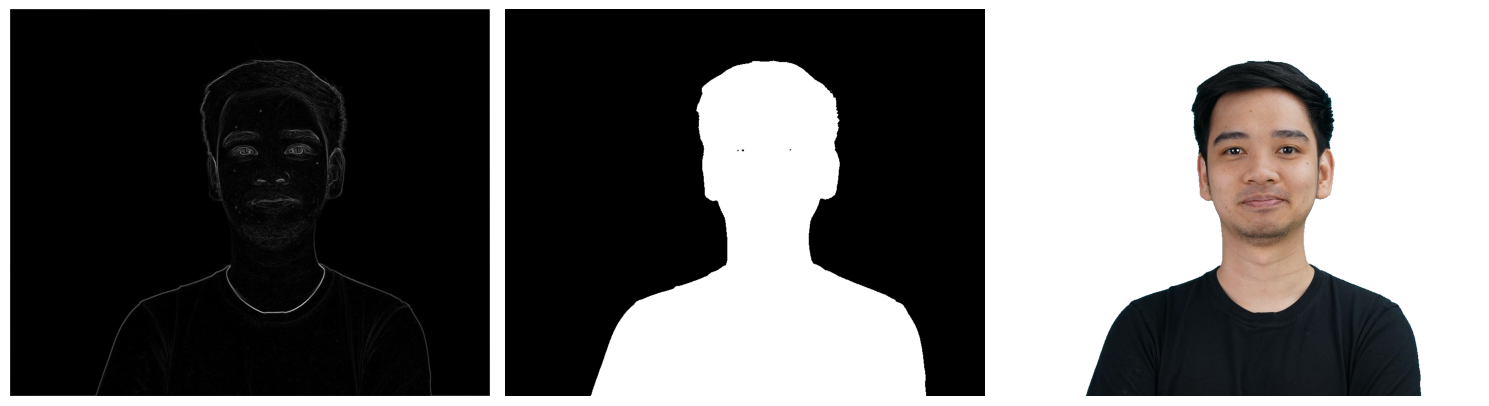

In [ ]:
sobel_davidX = convolution(davidAbu, sobelX)
sobel_davidY = convolution(davidAbu, sobelY)

sobel_david = np.abs(sobel_davidX) + np.abs(sobel_davidY)
sobel_david = sobel_david * 255.0 / np.max(sobel_david)
sobel_david = np.clip(sobel_david, 0, 255).astype(np.uint8)

red = davidRGB[:, :, 0].astype(np.float32)
green = davidRGB[:, :, 1].astype(np.float32)
blue = davidRGB[:, :, 2].astype(np.float32)
mask_background = (green > red) & (blue > red) & (green > 80) & (blue > 80)

mask_foreground = (~mask_background).astype(np.uint8) * 255
mask_foreground = filter(mask_foreground, 3, 'median')

hasil = davidRGB
hasil[mask_foreground == 0] = [255, 255, 255]


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sobel_david, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_foreground, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil)
plt.axis('off')

plt.tight_layout()
plt.show()

berdasarkan analisis untuk menghapus latar belakang dapat dilakukan dengan cara pertama, menggunakan konvolusi manual untuk menghitung magnitudo gradien Sobel untuk menonjolkan garis tepi objek yang kemudian dinormalisasi ke rentang 0-255; 

kedua, melakukan pemisahan latar belakang (background) berdasarkan edge warna hijau dan biru yang dominan, diikuti dengan penghalusan masker menggunakan filter median untuk menghilangkan noise. 

Hasil akhirnya adalah citra yang menampilkan objek utama secara bersih dengan latar belakang yang telah diubah menjadi putih polos.

## Analisis dan Kesimpulan

Kesimpulan dari praktikum ini menunjukkan bahwa proses perbaikan kualitas citra, seperti smoothing dan sharpening, berfungsi untuk mengurangi noise serta memperjelas detail objek sehingga citra menjadi lebih baik untuk dianalisis. Setelah tahap tersebut, dilakukan proses deteksi tepi menggunakan beberapa operator seperti Prewitt, Sobel, dan Roberts, serta teknik thresholding untuk mengekstraksi bentuk atau siluet objek dari latar belakang.

Secara umum, kombinasi berbagai teknik tersebut sangat penting dalam pengolahan citra digital karena mampu membantu proses identifikasi fitur-fitur penting pada gambar. Selain itu, metode ini juga mendukung segmentasi objek dan penghilangan latar belakang dengan lebih efektif, sehingga hasil citra yang diperoleh menjadi lebih jelas dan mudah diproses pada tahap analisis berikutnya.